In [14]:
import torch
import numpy as np
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.utils.transforms import normalize, unnormalize
from botorch.utils.sampling import draw_sobol_samples
from botorch.acquisition.multi_objective.parego import qLogNParEGO
from botorch.optim.optimize import optimize_acqf_list
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
torch.set_default_dtype(torch.float64)

In [15]:
# ────────────────────────────────────────────────
#  Objective function — both outputs to be maximized
# ────────────────────────────────────────────────

def objective_function(x: torch.Tensor) -> torch.Tensor:
    """
    Input:  (n × 100) tensor ∈ [0,1]^100
    Output: (n × 2) tensor — objectives to maximize
    """
    n, d = x.shape
    assert d == 100
    
    half = d // 2
    m1 = x[:, :half].mean(dim=1)
    m2 = x[:, half:].mean(dim=1)
    
    angle = 2.0 * np.pi * m2
    obj1 = m1 * torch.cos(angle)
    obj2 = m1 * torch.sin(angle)
    
    return -torch.stack([obj1, obj2], dim=-1)


dim = 100
bounds = torch.stack([torch.zeros(dim), torch.ones(dim)])

n_init = 128
batch_size = 4
n_iterations = 20

In [16]:
# ────────────────────────────────────────────────
#  Initial design
# ────────────────────────────────────────────────

X = draw_sobol_samples(bounds, n=1, q=n_init).squeeze(0)
X = torch.clamp(X, min=0.0, max=1.0)
Y = objective_function(X)

hv_history = []
pareto_history = []

print(f"Initial design generated: {X.shape[0]} points")

# Initial Pareto front
initial_mask = is_non_dominated(Y)
pareto_history.append(Y[initial_mask].clone())

Initial design generated: 128 points


In [17]:
# ────────────────────────────────────────────────
#  qLogNParEGO loop — maximization
# ────────────────────────────────────────────────

X_norm = normalize(X, bounds)
X_norm = torch.clamp(X_norm, min=0.0, max=1.0)

for it in range(n_iterations):
    gp = SingleTaskGP(X_norm, Y)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    
    sampler = SobolQMCNormalSampler(sample_shape=torch.Size([128]))
    
    acqf = qLogNParEGO(
        model=gp,
        X_baseline=X_norm,
        sampler=sampler,
        prune_baseline=True,
    )
    
    candidates_norm, _ = optimize_acqf_list(
        acq_function_list=[acqf] * batch_size,
        bounds=torch.stack([torch.zeros(dim), torch.ones(dim)]),
        num_restarts=8,
        raw_samples=256,
        options={"batch_limit": 5, "maxiter": 100},
    )
    
    X_new = unnormalize(candidates_norm, bounds)
    Y_new = objective_function(X_new)
    
    X = torch.cat([X, X_new], dim=0)
    Y = torch.cat([Y, Y_new], dim=0)
    
    X_norm = normalize(X, bounds)
    X_norm = torch.clamp(X_norm, min=0.0, max=1.0)
    
    print(f"Iter {it+1:3d} | Proposed {batch_size} points")
    
    # Hypervolume computation (maximization → nadir is minimum observed)
    nadir = Y.min(dim=0).values
    ref_point_hv = nadir - 0.1 * (Y.max(dim=0).values - nadir)
    partitioning = FastNondominatedPartitioning(ref_point=ref_point_hv, Y=Y)
    hv = partitioning.compute_hypervolume().item()
    hv_history.append(hv)
    print(f"   Hypervolume = {hv:.4e}")
    
    current_mask = is_non_dominated(Y)
    current_pareto = Y[current_mask].clone()
    pareto_history.append(current_pareto)
    print(f"   Pareto front size: {len(current_pareto)} points")

Iter   1 | Proposed 4 points
   Hypervolume = 1.0649e+00
   Pareto front size: 9 points
Iter   2 | Proposed 4 points
   Hypervolume = 1.0874e+00
   Pareto front size: 10 points
Iter   3 | Proposed 4 points
   Hypervolume = 1.2873e+00
   Pareto front size: 10 points


/home/mohamed/.local/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


Iter   4 | Proposed 4 points
   Hypervolume = 1.2873e+00
   Pareto front size: 10 points


/home/mohamed/.local/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


Iter   5 | Proposed 4 points
   Hypervolume = 1.3270e+00
   Pareto front size: 10 points
Iter   6 | Proposed 4 points
   Hypervolume = 1.5552e+00
   Pareto front size: 10 points
Iter   7 | Proposed 4 points
   Hypervolume = 1.6363e+00
   Pareto front size: 11 points
Iter   8 | Proposed 4 points
   Hypervolume = 1.7257e+00
   Pareto front size: 8 points
Iter   9 | Proposed 4 points
   Hypervolume = 1.7272e+00
   Pareto front size: 9 points


...

Iter  18 | Proposed 4 points
   Hypervolume = 1.8561e+00
   Pareto front size: 14 points


/home/mohamed/.local/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


Iter  19 | Proposed 4 points
   Hypervolume = 1.8561e+00
   Pareto front size: 14 points


/home/mohamed/.local/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/home/mohamed/.local/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed on the second try, after generating a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


Iter  20 | Proposed 4 points
   Hypervolume = 1.8561e+00
   Pareto front size: 14 points


In [18]:
# ────────────────────────────────────────────────
#  Final results — maximization scale
# ────────────────────────────────────────────────

final_mask = is_non_dominated(Y)
pareto_Y_final = Y[final_mask]

print("\nFinal approximate Pareto front (maximization, up to 15 points):")
print(pareto_Y_final[:15] if len(pareto_Y_final) > 0 else "No non-dominated points found.")

print(f"\nMaximum hypervolume achieved: {hv_history[-1]:.4e}")
print(f"Final Pareto front size: {len(pareto_Y_final)} points")

# Evolution summary
print("\nPareto front evolution summary:")
for i, front in enumerate(pareto_history):
    label = "Initial" if i == 0 else f"After iter {i}"
    hv_val = "N/A" if i == 0 else f"{hv_history[i-1]:.4e}"
    print(f"  {label:12s} | {len(front):3d} points | HV = {hv_val}")


Final approximate Pareto front (maximization, up to 15 points):
tensor([[0.1814, 0.9293],
        [0.3950, 0.8694],
        [0.1501, 0.9668],
        [0.2310, 0.9174],
        [0.2400, 0.8993],
        [0.4412, 0.8514],
        [0.5697, 0.7713],
        [0.3326, 0.8924],
        [0.4074, 0.8600],
        [0.5168, 0.8122],
        [0.6762, 0.7036],
        [0.5560, 0.7749],
        [0.5002, 0.8403],
        [0.4435, 0.8509]])

Maximum hypervolume achieved: 1.8561e+00
Final Pareto front size: 14 points

Pareto front evolution summary:
  Initial      |   7 points | HV = N/A
  After iter 1 |   9 points | HV = 1.0649e+00
  After iter 2 |  10 points | HV = 1.0874e+00
  After iter 3 |  10 points | HV = 1.2873e+00
  After iter 4 |  10 points | HV = 1.2873e+00
  After iter 5 |  10 points | HV = 1.3270e+00
  After iter 6 |  10 points | HV = 1.5552e+00
  After iter 7 |  11 points | HV = 1.6363e+00
  After iter 8 |   8 points | HV = 1.7257e+00
  After iter 9 |   9 points | HV = 1.7272e+00
  After

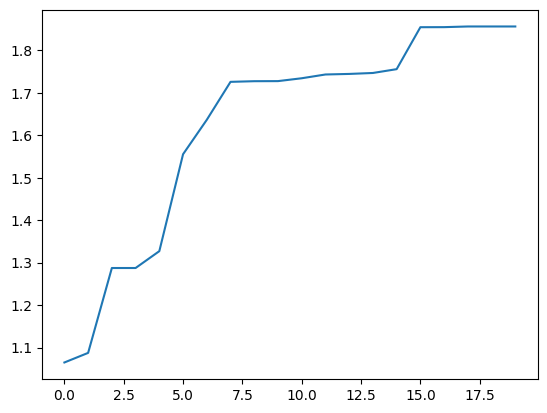

In [19]:
import matplotlib.pyplot as plt
plt.plot(hv_history)

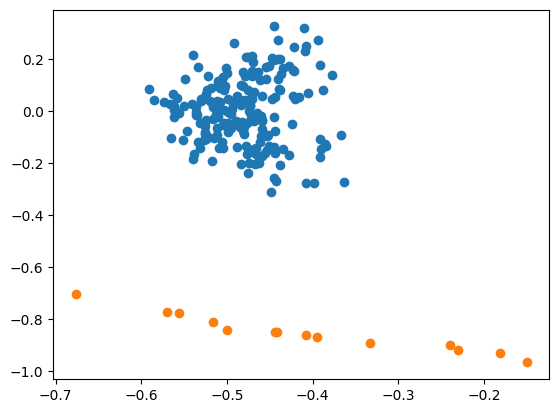

In [25]:
X = draw_sobol_samples(bounds, n=1, q=200).squeeze(0)
X = torch.clamp(X, min=0.0, max=1.0)
Y = objective_function(X)
plt.scatter(-Y[:, 0], -Y[:, 1])
plt.scatter(-pareto_history[-1][:,0], -pareto_history[-1][:, 1])